<a href="https://www.kaggle.com/code/adegbaju/poker-heads-up-model-analysis?scriptVersionId=302491447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Poker Heads-Up Model Analysis

#  Set up paths

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

In [2]:
# The actual files are inside a subdirectory called "PokerData"
input_dir = '/kaggle/input/datasets/organizations/kaggle/poker-heads-up/PokerData'

# If running locally, you can change this to the appropriate path
if not os.path.exists(input_dir):
    # Fallback for local testing
    input_dir = 'PokerData'

print(f"Looking for files in: {input_dir}")
files = [f for f in os.listdir(input_dir) if f.endswith('.txt') and '_vs_' in f]
print(f"Found {len(files)} matchup files.")


Looking for files in: /kaggle/input/datasets/organizations/kaggle/poker-heads-up/PokerData
Found 45 matchup files.


# Hand history parser

In [3]:
def parse_hand(lines):
    """
    Convert a list of lines representing one hand into a structured dict.
    Assumes a format similar to PokerStars hand histories.
    """
    hand = {
        'hand_id': None,
        'players': {},          # seat -> name
        'button_seat': None,
        'hole_cards': {},       # name -> list of cards
        'preflop_actions': [],
        'flop_actions': [],
        'turn_actions': [],
        'river_actions': [],
        'showdown': [],         # (player, cards)
        'winners': [],          # (player, amount)
        'pot': None,
    }

    current_street = 'preflop'

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Hand header
        m = re.match(r'Hand #?(\d+)', line)
        if m:
            hand['hand_id'] = int(m.group(1))
            continue

        # Seat assignments
        m = re.match(r'Seat (\d+): (.*?) \((\d+) in chips\)', line)
        if m:
            seat = int(m.group(1))
            name = m.group(2).strip()
            hand['players'][seat] = name
            continue

        # Button (two common formats)
        m = re.match(r'Seat (\d+) is the button', line)
        if m:
            hand['button_seat'] = int(m.group(1))
            continue
        m = re.match(r'Button: (.*)', line)
        if m:
            button_name = m.group(1).strip()
            for seat, name in hand['players'].items():
                if name == button_name:
                    hand['button_seat'] = seat
                    break
            continue

        # Hole cards
        m = re.match(r'Dealt to (.*?) \[(.*?)\]', line)
        if m:
            player = m.group(1).strip()
            cards = m.group(2).split()
            hand['hole_cards'][player] = cards
            continue

        # Street markers
        if line.startswith('*** FLOP ***'):
            current_street = 'flop'
            continue
        if line.startswith('*** TURN ***'):
            current_street = 'turn'
            continue
        if line.startswith('*** RIVER ***'):
            current_street = 'river'
            continue
        if line.startswith('*** SHOW DOWN ***'):
            current_street = 'showdown'
            continue
        if line.startswith('*** SUMMARY ***'):
            current_street = 'summary'
            continue

        # Player actions
        m = re.match(r'(.*?): (.*)', line)
        if m:
            player = m.group(1).strip()
            action_text = m.group(2).strip()

            # Classify action
            if action_text.startswith('folds'):
                action = 'fold'
                amount = None
            elif action_text.startswith('checks'):
                action = 'check'
                amount = None
            elif action_text.startswith('calls'):
                action = 'call'
                m_amount = re.search(r'calls (\d+)', action_text)
                amount = int(m_amount.group(1)) if m_amount else None
            elif action_text.startswith('bets'):
                action = 'bet'
                m_amount = re.search(r'bets (\d+)', action_text)
                amount = int(m_amount.group(1)) if m_amount else None
            elif action_text.startswith('raises'):
                action = 'raise'
                m_amount = re.search(r'raises (\d+)', action_text)
                amount = int(m_amount.group(1)) if m_amount else None
            elif action_text.startswith('posts'):
                action = 'post'
                m_amount = re.search(r'posts (?:small blind|big blind) (\d+)', action_text)
                amount = int(m_amount.group(1)) if m_amount else None
            else:
                action = None
                amount = None

            if action:
                act = {'player': player, 'action': action, 'amount': amount}
                if current_street == 'preflop':
                    hand['preflop_actions'].append(act)
                elif current_street == 'flop':
                    hand['flop_actions'].append(act)
                elif current_street == 'turn':
                    hand['turn_actions'].append(act)
                elif current_street == 'river':
                    hand['river_actions'].append(act)
                # actions during showdown are ignored
            continue

        # Showdown card reveals
        m = re.match(r'(.*?) shows \[(.*?)\]', line)
        if m:
            player = m.group(1).strip()
            cards = m.group(2).split()
            hand['showdown'].append((player, cards))
            continue

        # Winner lines
        m = re.match(r'(.*?) collected (\d+) from pot', line)
        if m:
            player = m.group(1).strip()
            amount = int(m.group(2))
            hand['winners'].append((player, amount))
            continue
        m = re.match(r'(.*?) wins (\d+)', line)
        if m:
            player = m.group(1).strip()
            amount = int(m.group(2))
            hand['winners'].append((player, amount))
            continue

        # Total pot
        m = re.match(r'Total pot (\d+)', line)
        if m:
            hand['pot'] = int(m.group(1))
            continue

    if not hand['players']:
        return None
    return hand


#  Update per‑player statistics from a parsed hand

In [4]:
def update_stats(stats, hand):
    """
    stats: dict of player -> defaultdict(int)
    hand: dict from parse_hand()
    """
    players_in_hand = list(hand['players'].values())
    winners = [w[0] for w in hand['winners']]

    for player in players_in_hand:
        if player not in stats:
            stats[player] = defaultdict(int)

    # Count hands played
    for player in players_in_hand:
        stats[player]['hands'] += 1

    # VPIP and PFR from preflop actions
    vpip_players = set()
    pfr_players = set()
    for action in hand['preflop_actions']:
        if action['action'] in ('call', 'bet', 'raise'):
            vpip_players.add(action['player'])
            if action['action'] == 'raise':
                pfr_players.add(action['player'])

    for player in players_in_hand:
        if player in vpip_players:
            stats[player]['vpip'] += 1
        if player in pfr_players:
            stats[player]['pfr'] += 1

    # Track folds to determine who stayed until showdown
    folded_players = set()
    all_actions = (hand['preflop_actions'] + hand.get('flop_actions', []) +
                   hand.get('turn_actions', []) + hand.get('river_actions', []))
    for action in all_actions:
        if action['action'] == 'fold':
            folded_players.add(action['player'])

    # Showdown / wins
    if hand['showdown']:          # hand went to showdown
        for player in players_in_hand:
            if player not in folded_players:
                stats[player]['showdowns'] += 1
                if player in winners:
                    stats[player]['wins_showdown'] += 1
    else:
        # Non‑showdown hand: exactly one winner (the last player standing)
        if winners:
            # In heads‑up, there should be exactly one winner
            stats[winners[0]]['wins_nonshowdown'] += 1

    # Aggression actions (bets/raises vs calls/checks)
    for action in all_actions:
        player = action['player']
        if action['action'] in ('bet', 'raise'):
            stats[player]['agg_actions'] += 1
        elif action['action'] in ('call', 'check'):
            stats[player]['passive_actions'] += 1

    # Net chips won/lost: each winner gains pot amount, but we need to track contributions.
    # A simpler approach: for each hand, sum up chips that each player puts in (from posts and bets)
    # and then net = (amount won from pot) - (total put in).
    # We'll compute contributions from posts and actions with amounts.
    # Initialize contribution for each player in this hand.
    contribution = {player: 0 for player in players_in_hand}
    for action in all_actions:
        if action['action'] in ('post', 'call', 'bet', 'raise') and action['amount']:
            contribution[action['player']] += action['amount']
    # Winners get the pot (minus their own contribution already counted)
    for player, amount in hand['winners']:
        stats[player]['chips_won'] += amount
        # The pot amount includes the player's own bet, so net = amount_won - contribution
        stats[player]['net_chips'] += (amount - contribution[player])
        # For losers, we already added their contribution; we subtract it later.
    # For players who did not win, their net change is -contribution.
    for player in players_in_hand:
        if player not in [w[0] for w in hand['winners']]:
            stats[player]['net_chips'] -= contribution[player]


# Process all files

In [5]:
stats = defaultdict(lambda: defaultdict(int))

for filename in files:
    filepath = os.path.join(input_dir, filename)
    print(f"Processing {filename} ...")
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        hand_lines = []
        for line in f:
            if re.match(r'Hand #?\d+', line):
                if hand_lines:
                    hand = parse_hand(hand_lines)
                    if hand:
                        update_stats(stats, hand)
                hand_lines = [line]
            else:
                hand_lines.append(line)
        # Last hand
        if hand_lines:
            hand = parse_hand(hand_lines)
            if hand:
                update_stats(stats, hand)

print("\nProcessing complete.")

Processing DeepSeek_V3.2_vs_Gemini_3_Pro_Preview.txt ...
Processing Claude_Sonnet_4.5_vs_o3.txt ...
Processing Claude_Sonnet_4.5_vs_GPT-5.2.txt ...
Processing Claude_Opus_4.5_vs_Claude_Sonnet_4.5.txt ...
Processing Claude_Opus_4.5_vs_GPT-5_mini.txt ...
Processing Claude_Opus_4.5_vs_GPT-5.2.txt ...
Processing GPT-5.2_vs_Grok_4.1_Fast_Reasoning.txt ...
Processing GPT-5_mini_vs_Gemini_3_Flash_Preview.txt ...
Processing Claude_Sonnet_4.5_vs_Gemini_3_Pro_Preview.txt ...
Processing Gemini_3_Pro_Preview_vs_o3.txt ...
Processing GPT-5.2_vs_Gemini_3_Pro_Preview.txt ...
Processing Claude_Opus_4.5_vs_Gemini_3_Flash_Preview.txt ...
Processing Gemini_3_Pro_Preview_vs_Grok_4.txt ...
Processing GPT-5_mini_vs_Grok_4.1_Fast_Reasoning.txt ...
Processing GPT-5_mini_vs_Grok_4.txt ...
Processing Grok_4_vs_o3.txt ...
Processing Grok_4_vs_Grok_4.1_Fast_Reasoning.txt ...
Processing Claude_Sonnet_4.5_vs_Grok_4.txt ...
Processing Claude_Opus_4.5_vs_o3.txt ...
Processing Gemini_3_Flash_Preview_vs_Grok_4.1_Fast_R

# Build summary DataFrame

In [6]:
import pandas as pd
summary = []
for player, data in stats.items():
    hands = data['hands']
    if hands == 0:
        continue
    vpip = data['vpip'] / hands * 100
    pfr = data['pfr'] / hands * 100
    wins_showdown = data.get('wins_showdown', 0)
    wins_nonshowdown = data.get('wins_nonshowdown', 0)
    total_wins = wins_showdown + wins_nonshowdown
    win_rate = total_wins / hands * 100
    showdowns = data.get('showdowns', 0)
    showdown_win_rate = (wins_showdown / showdowns * 100) if showdowns > 0 else 0
    non_showdown_rate = (wins_nonshowdown / (hands - showdowns) * 100) if (hands - showdowns) > 0 else 0

    agg = data.get('agg_actions', 0)
    passive = data.get('passive_actions', 0)
    if passive > 0:
        af = agg / passive
    else:
        af = float('inf') if agg > 0 else 0

    summary.append({
        'Player': player,
        'Hands': hands,
        'Net Chips': data.get('net_chips', 0),
        'Win%': round(win_rate, 2),
        'VPIP%': round(vpip, 2),
        'PFR%': round(pfr, 2),
        'Showdowns': showdowns,
        'Wins@SD': wins_showdown,
        'SD Win%': round(showdown_win_rate, 2),
        'Wins_nonSD': wins_nonshowdown,
        'nonSD Win%': round(non_showdown_rate, 2),
        'AggFactor': round(af, 2) if af != float('inf') else '∞'
    })

# Sort by net chips (or win rate) descending
summary.sort(key=lambda x: x['Net Chips'], reverse=True)
df = pd.DataFrame(summary)


# Display and save results


POKER MODEL LEADERBOARD (sorted by Net Chips)
                 Player  Hands  Net Chips  Win%  VPIP%   PFR%  Showdowns  Wins@SD  SD Win%  Wins_nonSD  nonSD Win%  AggFactor
   Gemini 3 Pro Preview      9    -814536   0.0  33.33   0.00          0        0        0           0         0.0       0.11
 Gemini 3 Flash Preview      9   -1285198   0.0  88.89  88.89          0        0        0           0         0.0       0.23
             GPT-5 mini      9   -1841784   0.0  88.89  55.56          0        0        0           0         0.0       0.62
        Claude Opus 4.5      9   -1844912   0.0  77.78  33.33          0        0        0           0         0.0       0.48
                GPT-5.2      9   -2181969   0.0  88.89  88.89          0        0        0           0         0.0       0.62
      Claude Sonnet 4.5      9   -2296803   0.0  88.89  33.33          0        0        0           0         0.0       0.81
          DeepSeek V3.2      9   -2303561   0.0  77.78   0.00          

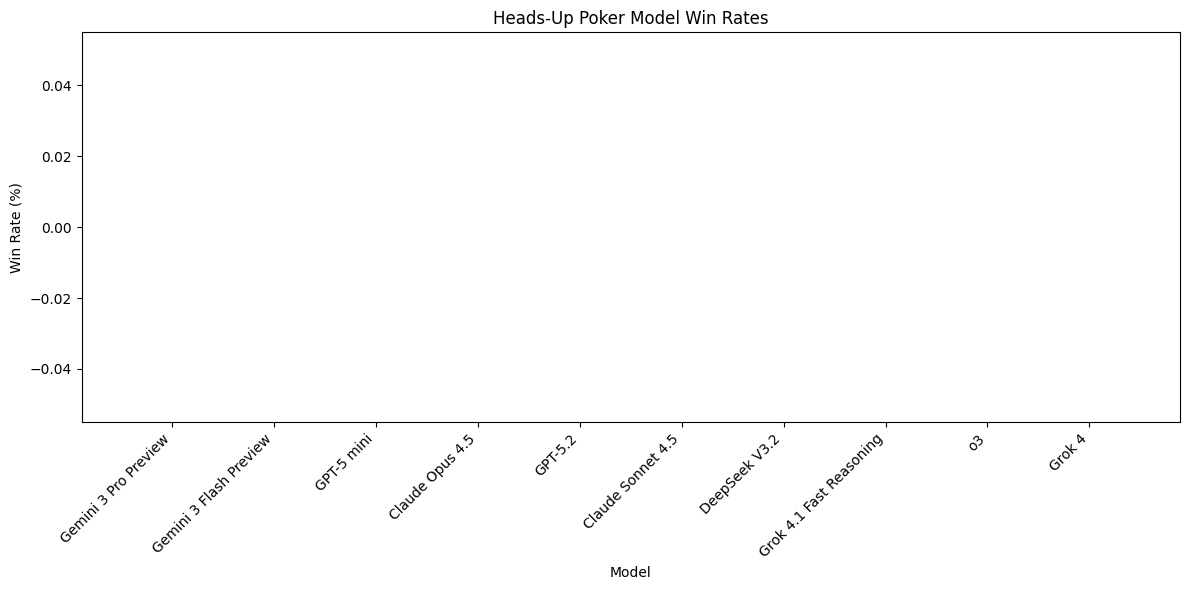

In [7]:
print("\n" + "=" * 100)
print("POKER MODEL LEADERBOARD (sorted by Net Chips)")
print("=" * 100)
print(df.to_string(index=False))

# Save to CSV
df.to_csv('poker_model_stats.csv', index=False)
print("\nStats saved to poker_model_stats.csv")

# Optional: bar chart of win rates
plt.figure(figsize=(12,6))
plt.bar(df['Player'], df['Win%'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('Win Rate (%)')
plt.title('Heads-Up Poker Model Win Rates')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('win_rates.png')
plt.show()